In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [3]:
titanic=sns.load_dataset("titanic")

In [7]:
titanic.head()
titanic.describe()
titanic.info()
titanic.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [9]:
feature = ["pclass","sex","fare","embarked","age"]
target=["survived"]

In [10]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [12]:
# Missing data
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy="median")
titanic[["age"]]=imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

In [14]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [15]:
titanic.shape

(891, 15)

In [16]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [18]:
# Encode
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

titanic["sex"] =le.fit_transform(titanic["sex"])
titanic["embarked"] =le.fit_transform(titanic["embarked"])


In [19]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [21]:
X = titanic[feature]
y = titanic[target]

In [33]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [34]:
X_train.head()

,pclass,sex,fare,embarked,age
331,1,1,28.5000,2,45.5
733,2,1,13.0000,2,23.0
382,3,1,7.9250,2,32.0
704,3,1,7.8542,2,26.0
813,3,0,31.2750,2,6.0


In [35]:
# Decision Tree Model -- no prining
from sklearn.tree import DecisionTreeClassifier

model= DecisionTreeClassifier()
model.fit(X_train,y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [38]:
from sklearn.metrics import accuracy_score
y_pred=model.predict(X_test)

print("accuracy :",accuracy_score(y_test,y_pred))

accuracy : 0.7653631284916201


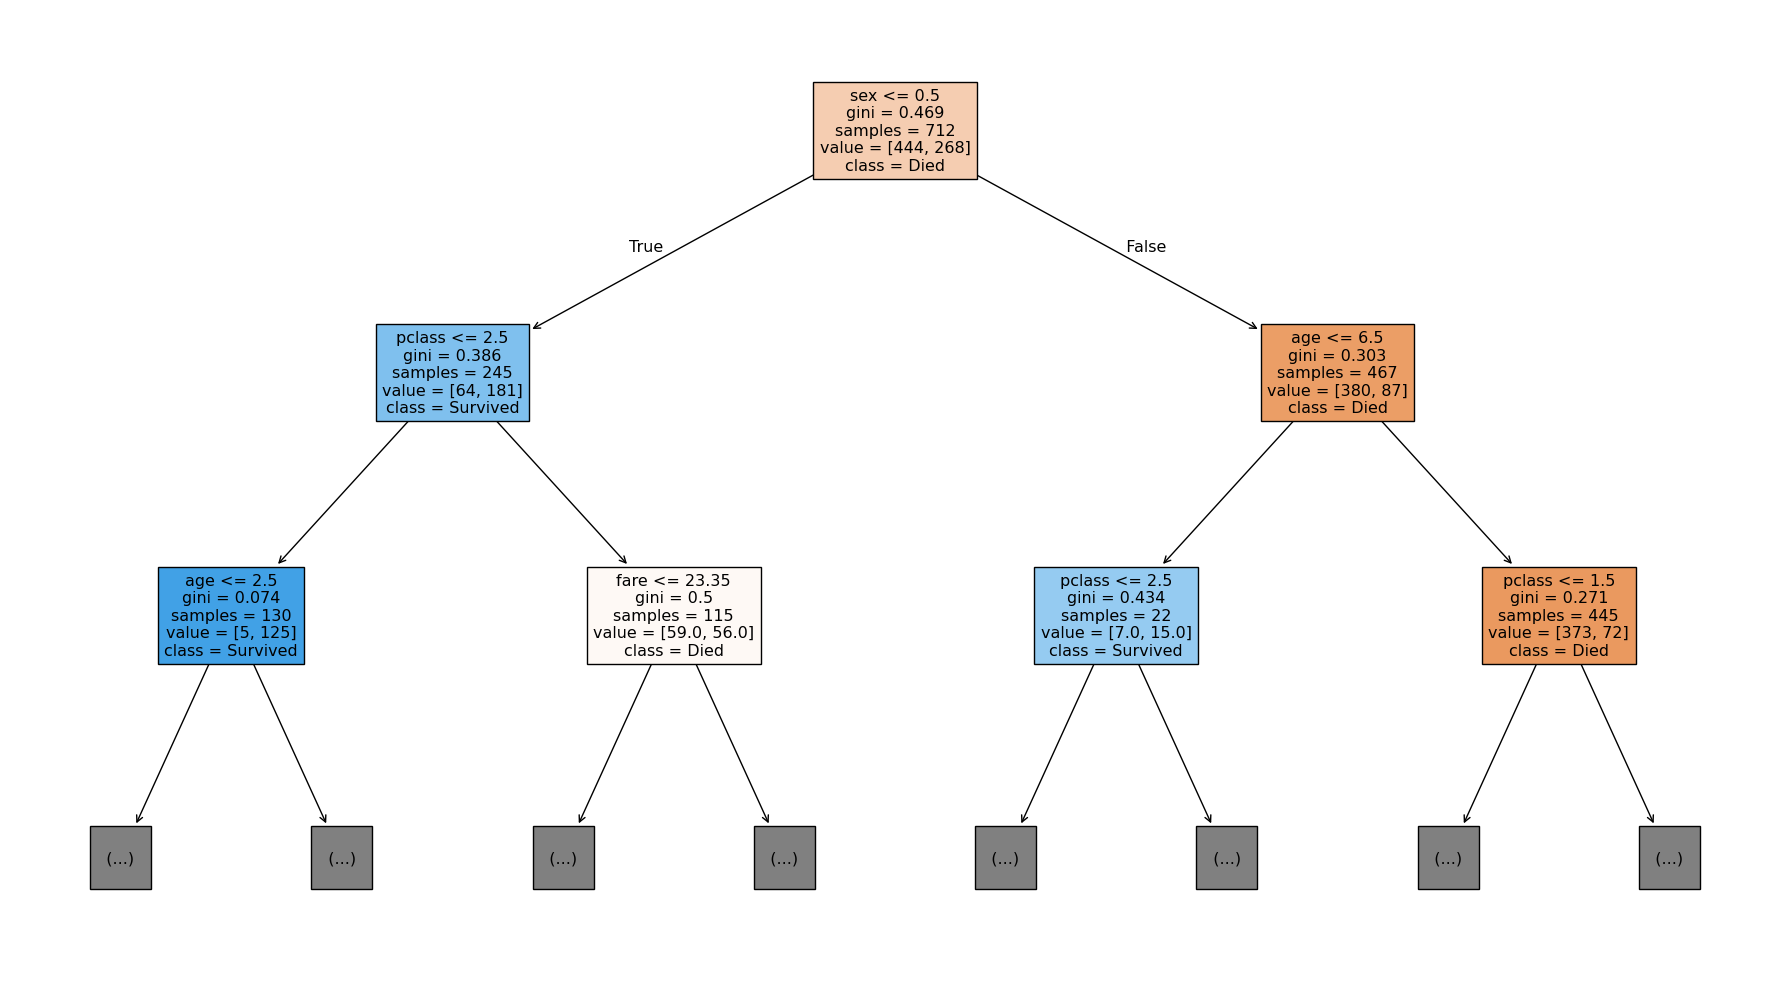

In [44]:
from sklearn.tree import plot_tree 

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True,
    max_depth=2
    
)
plt.tight_layout()
plt.show()

In [45]:
X.head()

,pclass,sex,fare,embarked,age
0,3,1,7.2500,2,22.0
1,1,0,71.2833,0,38.0
2,3,0,7.9250,2,26.0
3,1,0,53.1000,2,35.0
4,3,1,8.0500,2,35.0


In [46]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


# Decision Tree Classifier (pre-pruning)

for depth=2, accuracy : 0.7653631284916201
for depth=3, accuracy : 0.7988826815642458
for depth=4, accuracy : 0.7988826815642458


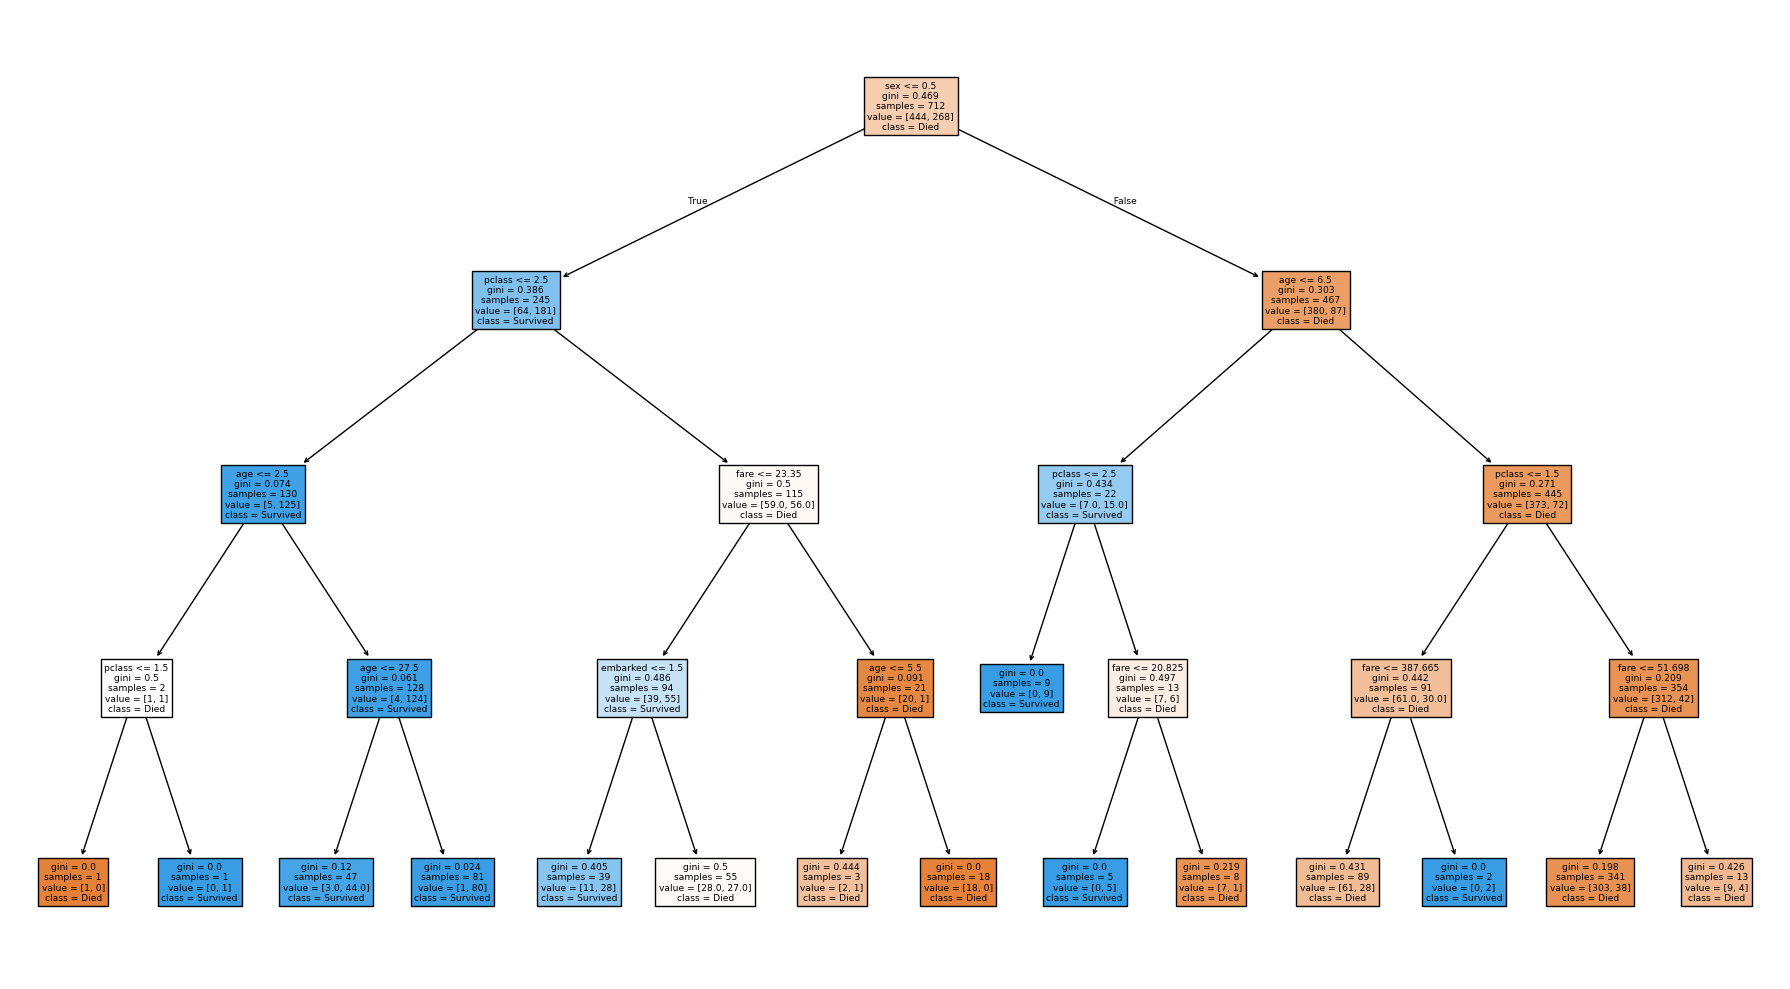

for depth=5, accuracy : 0.7988826815642458
for depth=6, accuracy : 0.8044692737430168
for depth=7, accuracy : 0.7877094972067039
for depth=8, accuracy : 0.7932960893854749
for depth=9, accuracy : 0.7932960893854749
for depth=10, accuracy : 0.7932960893854749


In [52]:
max_depth=[2,3,4,5,6,7,8,9,10]

for depth in max_depth:

    model= DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train,y_train)

    acc=model.score(X_test,y_test)
    print(f"for depth={depth}, accuracy : {acc}")

    if depth==4:
        plt.figure(figsize=(18,10))
        plot_tree(
            model,
            feature_names=X.columns,
            class_names=["Died","Survived"],
            filled=True            
        )
        plt.tight_layout()
        plt.show()
        

In [50]:
min_sample_splits=[10,15,20,25,30]

for split in min_sample_splits:
    model= DecisionTreeClassifier(max_depth=4,min_samples_split=split)
    model.fit(X_train,y_train)

    acc=model.score(X_test,y_test)
    print(f"for sample split={split}, accuracy : {acc}")

    if split==10:
        plt.figure(figsize=(18,10))
        plot_tree(
            model,
            feature_names=X.columns,
            class_names=["Died","Survived"],
            filled=True            
        )
        plt.tight_layout()
        plt.show()

for sample split=10, accuracy : 0.7988826815642458
for sample split=15, accuracy : 0.7988826815642458
for sample split=20, accuracy : 0.7988826815642458
for sample split=25, accuracy : 0.7932960893854749
for sample split=30, accuracy : 0.7932960893854749
